In [4]:
# %%capture
# %run /Users/norahmiller/Desktop/adcs-project/HW1/HW1_4_5.ipynb
# %run /Users/norahmiller/Desktop/adcs-project/HW1/TESS_GeometricModel.ipynb
# %run /Users/norahmiller/Desktop/adcs-project/HW2/HW2_Problem1.ipynb
# %run /Users/norahmiller/Desktop/adcs-project/HW2/HW2_Problem3.ipynb

In [5]:
%%capture
%run ../HW1/HW1-4-5.ipynb
%run ../HW1/TESS_GeometricModel.ipynb
%run ./HW2_Problem1.ipynb
%run ./HW2_Problem3.ipynb

TypeError: dynamics() takes 1 positional argument but 2 were given

TypeError: dynamics() takes 1 positional argument but 2 were given

In [6]:
print("Imported HW1 Sucessfully")

Imported HW1 Sucessfully


In [7]:
import numpy as np
from scipy.linalg import expm
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

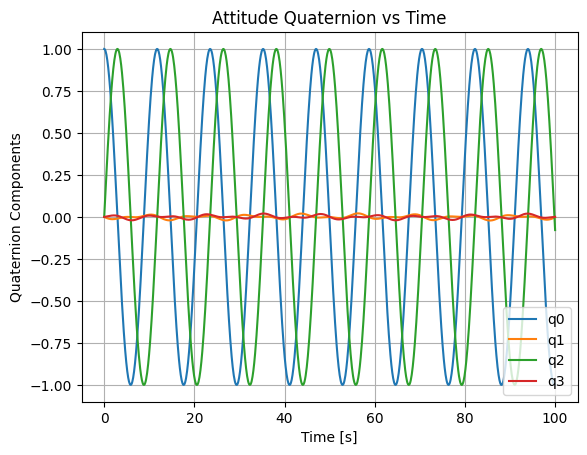

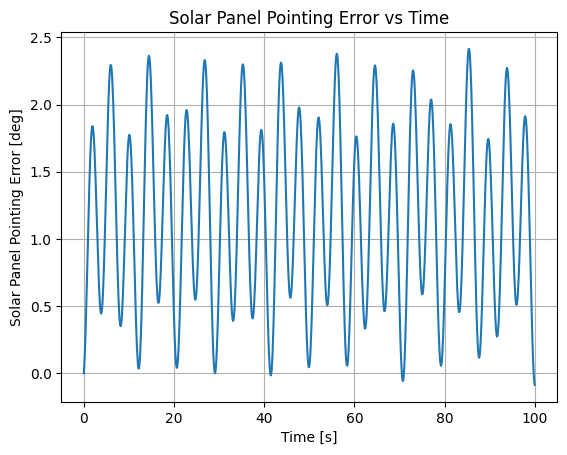

In [8]:
# Initial conditions
r0 = np.array([7000, 0, 0])  # km
v0 = np.array([0, 7.5, 0])   # km/s

state0 = np.concatenate([r0, v0, q0 , w0, rho0])

def full_dynamics(t, x, J):

    r = x[0:3]
    v = x[3:6]
    q = x[6:10]
    w = x[10:13]
    rho = x[13:16]

    q = q / np.linalg.norm(q)

    # ORBIT
    mu = 398600.4418
    r_norm = np.linalg.norm(r)
    a = -mu * r / r_norm**3

    # ATTITUDE (same as 1.4)
    q_dot = 0.5 * G(q) @ w
    w_dot = -np.linalg.solve(J, hat(w) @ (J @ w + rho))
    rho_dot = np.zeros(3)

    return np.hstack([v, a, q_dot, w_dot, rho_dot])

# Integrate
tspan = (0, 100)  # seconds (several nutation periods)
sol = solve_ivp(lambda t, y: full_dynamics(t, y, J),
                tspan, state0, rtol=1e-9, atol=1e-12)


# Extract results
q_sol = sol.y[6:10,:]  # quaternion
omega_sol = sol.y[10:13,:]

# Solar panel pointing
n_B = np.array([0,1,0])
s_ECI = np.array([1,0,0])

q_sol_cont = q_sol.copy()

pointing_error = []

for k in range(q_sol_cont.shape[1]):
    qk = q_sol_cont[:, k]
    q0,q1,q2,q3 = qk
    R = np.array([
        [1-2*(q2**2+q3**2), 2*(q1*q2-q0*q3), 2*(q1*q3+q0*q2)],
        [2*(q1*q2+q0*q3), 1-2*(q1**2+q3**2), 2*(q2*q3-q0*q1)],
        [2*(q1*q3-q0*q2), 2*(q2*q3+q0*q1), 1-2*(q1**2+q2**2)]
    ])
    n_ECI = R @ n_B
    err = np.arccos(np.clip(np.dot(n_ECI, s_ECI)/np.linalg.norm(n_ECI), -1,1))
    pointing_error.append(np.degrees(err))

pointing_error = np.array(pointing_error)

# Plot results
t = sol.t
q_norm = np.sqrt(np.sum(q_sol**2, axis=0))
plt.figure()
plt.plot(t, q_sol.T)
plt.xlabel('Time [s]')
plt.ylabel('Quaternion Components')
plt.title('Attitude Quaternion vs Time')
plt.legend(['q0','q1','q2','q3'])
plt.grid()

plt.figure()
plt.plot(t, pointing_error-90)
plt.xlabel('Time [s]')
plt.ylabel('Solar Panel Pointing Error [deg]')
plt.title('Solar Panel Pointing Error vs Time')
plt.grid()
plt.show()

## 4. Comparison of Accuracy + Computational Cost for Solving Wahba's Problem ##

In [9]:
# un hat
def unhat(S):
    return 0.5 * np.array([
        S[2,1] - S[1,2],
        S[0,2] - S[2,0],
        S[1,0] - S[0,1]
    ])


# constants
H = np.vstack([np.zeros((1,3)), np.eye(3)])

T = np.block([
    [np.ones((1,1)), np.zeros((1,3))],
    [np.zeros((3,1)), -np.eye(3)]
])


# quaternion left multiplication matrix
def L(q):
    q = np.asarray(q)
    q0 = q[0]
    qv = q[1:4]

    top = np.hstack([q0, -qv])
    bottom = np.hstack([
        qv.reshape(3,1),
        q0*np.eye(3) + hat(qv)
    ])

    return np.vstack([top, bottom])


# quaternion right multiplication matrix
def R(q):
    q = np.asarray(q)
    q0 = q[0]
    qv = q[1:4]

    top = np.hstack([q0, -qv])
    bottom = np.hstack([
        qv.reshape(3,1),
        q0*np.eye(3) - hat(qv)
    ])

    return np.vstack([top, bottom])


def G(q):
    return L(q) @ H


def Q(q):
    return H.T @ (R(q).T @ L(q)) @ H


# quaternion exponential
def expq(phi):
    phi = np.asarray(phi)
    theta = np.linalg.norm(phi)

    return np.concatenate([
        [np.cos(theta)],
        phi * np.sinc(theta/np.pi)
    ])

In [10]:
import numpy as np
import time
from scipy.linalg import logm

# -------------------------
# Assume you already have:
# star_measurements (N x 3)
# cam_measurements (N x 3)
# Also have cov_star and cov_cam
# -------------------------
Nmc = 5000
errors_davenport = np.zeros(Nmc)
errors_dyn = np.zeros(Nmc)
errors_newton = np.zeros(Nmc)
errors_triad = np.zeros(Nmc)
time_davenport = 0.0
time_dyn = 0.0
time_newton = 0.0
time_triad = 0.0

# Define 3 “true star directions” in body frame
r_B_true = np.array([[1,0,0],
                     [0,1,0],
                     [0,0,1]]).T  # shape (3,3)

for i in range(Nmc):

    # True attitude
    qtrue = expq(0.5*np.random.rand(3))
    Qtrue = Q(qtrue)

    # Apply true rotation to get inertial directions
    r_N_true = Qtrue @ r_B_true

    # Add realistic noise from star tracker and camera
    r_B_noisy = np.zeros_like(r_B_true, dtype=float)
    for k in range(r_B_true.shape[1]):
        # Randomly choose which sensor to simulate for this vector
        if np.random.rand() < 0.5:  # 50% chance
            noise = np.random.multivariate_normal(np.zeros(3), cov_star)
        else:
            noise = np.random.multivariate_normal(np.zeros(3), cov_cam)
        r_B_noisy[:,k] = r_B_true[:,k] + noise
        r_B_noisy[:,k] /= np.linalg.norm(r_B_noisy[:,k])

    r_B = r_B_noisy
    r_N = r_N_true

    w = (1/r_B.shape[1])*np.ones(r_B.shape[1])  # equal weights

    # -------------------------
    # Davenport q-method
    # -------------------------
    start = time.time()
    B_mat = np.zeros((3,3))
    for k in range(r_B.shape[1]):
        B_mat += w[k] * np.outer(r_B[:,k], r_N[:,k])
    S = B_mat + B_mat.T
    sigma_trace = np.trace(B_mat)
    Z = np.array([B_mat[1,2]-B_mat[2,1], B_mat[2,0]-B_mat[0,2], B_mat[0,1]-B_mat[1,0]])
    K = np.zeros((4,4))
    K[0,0] = sigma_trace
    K[0,1:] = Z
    K[1:,0] = Z
    K[1:,1:] = S - sigma_trace*np.eye(3)
    eigvals, eigvecs = np.linalg.eigh(K)
    q_dav = eigvecs[:, np.argmax(eigvals)]
    R_err = Q(q_dav).T @ Qtrue
    phi = unhat(logm(R_err))
    errors_davenport[i] = (180/np.pi)*np.linalg.norm(phi)
    time_davenport += time.time() - start

    # -------------------------
    # Dynamic SVD
    # -------------------------
    start = time.time()
    U, _, Vt = np.linalg.svd(B_mat)
    R_dyn = U @ Vt
    if np.linalg.det(R_dyn) < 0:
        U[:,2] *= -1
        R_dyn = U @ Vt
    R_err = R_dyn.T @ Qtrue
    phi = unhat(logm(R_err))
    errors_dyn[i] = (180/np.pi)*np.linalg.norm(phi)
    time_dyn += time.time() - start

    # -------------------------
    # Newton's method
    # -------------------------
    start = time.time()
    S = B_mat + B_mat.T
    sigma = np.trace(B_mat)
    Z = np.array([B_mat[1,2]-B_mat[2,1], B_mat[2,0]-B_mat[0,2], B_mat[0,1]-B_mat[1,0]])
    K = np.zeros((4,4))
    K[0,0] = sigma
    K[0,1:] = Z
    K[1:,0] = Z
    K[1:,1:] = S - sigma*np.eye(3)
    eigvals, eigvecs = np.linalg.eigh(K)
    q_newton = eigvecs[:, np.argmax(eigvals)]
    R_err = Q(q_newton).T @ Qtrue
    phi = unhat(logm(R_err))
    errors_newton[i] = (180/np.pi)*np.linalg.norm(phi)
    time_newton += time.time() - start

NameError: name 'cov_cam' is not defined

Mean Errors
q-method: 0.0012854510089429917
SVD: 110.53304468715083
Newton's Method': 0.0012854510089429917

Std Dev
q-method: 0.0007111644698649482
SVD: 31.724792186703016
Newton's Method: 0.0007111644698649482

Average Time per Trial (ms)
q-method: 0.48797097206115725
SVD: 0.6719544887542724
Newton's Method: 0.47729339599609377


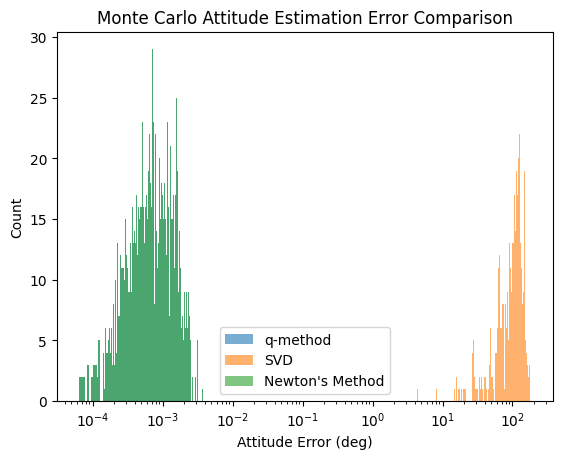

In [ ]:
# Results
 
print("Mean Errors")
print("q-method:", np.mean(errors_davenport))
print("SVD:", np.mean(errors_dyn))
print("Newton's Method':", np.mean(errors_newton))

print("\nStd Dev")
print("q-method:", np.std(errors_davenport))
print("SVD:", np.std(errors_dyn))
print("Newton's Method:", np.std(errors_newton))


print("\nAverage Time per Trial (ms)")
print("q-method:", 1000*time_davenport/Nmc)
print("SVD:", 1000*time_dyn/Nmc)
print("Newton's Method:", 1000*time_newton/Nmc)

 
# Histogram
plt.hist(errors_davenport, bins=700, alpha=0.6, label="q-method")
plt.hist(errors_dyn, bins=700, alpha=0.6, label="SVD")
plt.hist(errors_newton, bins=700, alpha=0.6, label="Newton's Method")


plt.xlabel("Attitude Error (deg)")
plt.ylabel("Count")
plt.xscale('log')
plt.legend()
plt.title("Monte Carlo Attitude Estimation Error Comparison")
plt.show()